# SARSA no Labirinto
O agente parte do canto superior esquerdo e aprende a chegar ao canto inferior direito.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import sys

sys.setrecursionlimit(10000)  # necessário para labirintos grandes (100x100+)
random.seed(42)
np.random.seed(42)

## 1. Gerar o Labirinto

In [38]:
SIZE = 50  # labirinto 20x20 (fácil de visualizar)

# O DFS precisa de SIZE ímpar para bordas limpas — ajusta automaticamente
if SIZE % 2 == 0:
    SIZE += 1

def gerar_labirinto(size, seed=42):
    """Gera um labirinto aleatório usando o algoritmo DFS."""
    np.random.seed(seed)
    random.seed(seed)
    maze = [[1]*size for _ in range(size)]  # 1 = parede

    def visitar(r, c):
        maze[r][c] = 0  # 0 = livre
        dirs = [(0,2),(0,-2),(2,0),(-2,0)]
        random.shuffle(dirs)
        for dr, dc in dirs:
            nr, nc = r+dr, c+dc
            # permanece dentro do interior — bordas nunca são abertas
            if 1 <= nr < size-1 and 1 <= nc < size-1 and maze[nr][nc] == 1:
                maze[r+dr//2][c+dc//2] = 0  # abre parede entre
                visitar(nr, nc)

    visitar(1, 1)
    m = np.array(maze)
    # Garante borda fechada independente do tamanho
    m[0, :] = m[-1, :] = m[:, 0] = m[:, -1] = 1
    return m

maze = gerar_labirinto(SIZE)
START = (1, 1)
GOAL  = (SIZE-2, SIZE-2)

print(f"Labirinto {SIZE}x{SIZE} gerado. Início: {START}, Meta: {GOAL}")

Labirinto 51x51 gerado. Início: (1, 1), Meta: (49, 49)


## 2. Treinar o Agente com SARSA

In [39]:
# Hiperparâmetros
alpha   = 0.2    # taxa de aprendizado
gamma   = 0.99   # desconto
epsilon = 1.0    # exploração inicial
episodios = 10000

# Ações: cima, baixo, esquerda, direita
acoes = [(-1,0),(1,0),(0,-1),(0,1)]

# Q-table: (linha, coluna, ação)
Q = np.zeros((SIZE, SIZE, 4))

def escolher_acao(r, c, eps):
    """Escolhe ação com epsilon-greedy."""
    if np.random.rand() < eps:
        return np.random.randint(4)
    return int(np.argmax(Q[r, c]))

def passo(r, c, a):
    """Executa ação e retorna novo estado e recompensa."""
    dr, dc = acoes[a]
    nr, nc = r+dr, c+dc
    if 0 <= nr < SIZE and 0 <= nc < SIZE and maze[nr, nc] == 0:
        r, c = nr, nc
    recompensa = 100 if (r, c) == GOAL else -1
    return r, c, recompensa

recompensas = []
passos_por_ep = []      # passos por episódio
sucessos      = []      # 1 se chegou à meta, 0 caso contrário
epsilons      = []      # valor de epsilon em cada episódio

for ep in range(episodios):
    r, c = START
    a = escolher_acao(r, c, epsilon)
    total  = 0
    passos = 0

    for _ in range(2000):
        nr, nc, recomp = passo(r, c, a)
        na = escolher_acao(nr, nc, epsilon)

        # Equação SARSA
        Q[r,c,a] += alpha * (recomp + gamma * Q[nr,nc,na] - Q[r,c,a])

        r, c, a = nr, nc, na
        total  += recomp
        passos += 1
        if (r, c) == GOAL:
            break

    recompensas.append(total)
    passos_por_ep.append(passos)
    sucessos.append(1 if (r, c) == GOAL else 0)
    epsilons.append(epsilon)
    epsilon = max(0.01, epsilon * 0.99)

print("Treinamento concluído!")

Treinamento concluído!


## 3. Extrair o Caminho Aprendido

In [40]:
def caminho_greedy():
    """Plotar caminho"""
    r, c = START
    caminho = [(r, c)]
    visitados = {(r, c)}
    for _ in range(5000):
        a = int(np.argmax(Q[r, c]))
        nr, nc, _ = passo(r, c, a)
        if (nr, nc) in visitados:
            break
        r, c = nr, nc
        caminho.append((r, c))
        visitados.add((r, c))
        if (r, c) == GOAL:
            break
    return caminho

caminho = caminho_greedy()
chegou  = caminho[-1] == GOAL
print(f"Meta atingida: {'SIM' if chegou else 'NÃO'} | Passos: {len(caminho)}")

Meta atingida: SIM | Passos: 529


## 4. Visualização

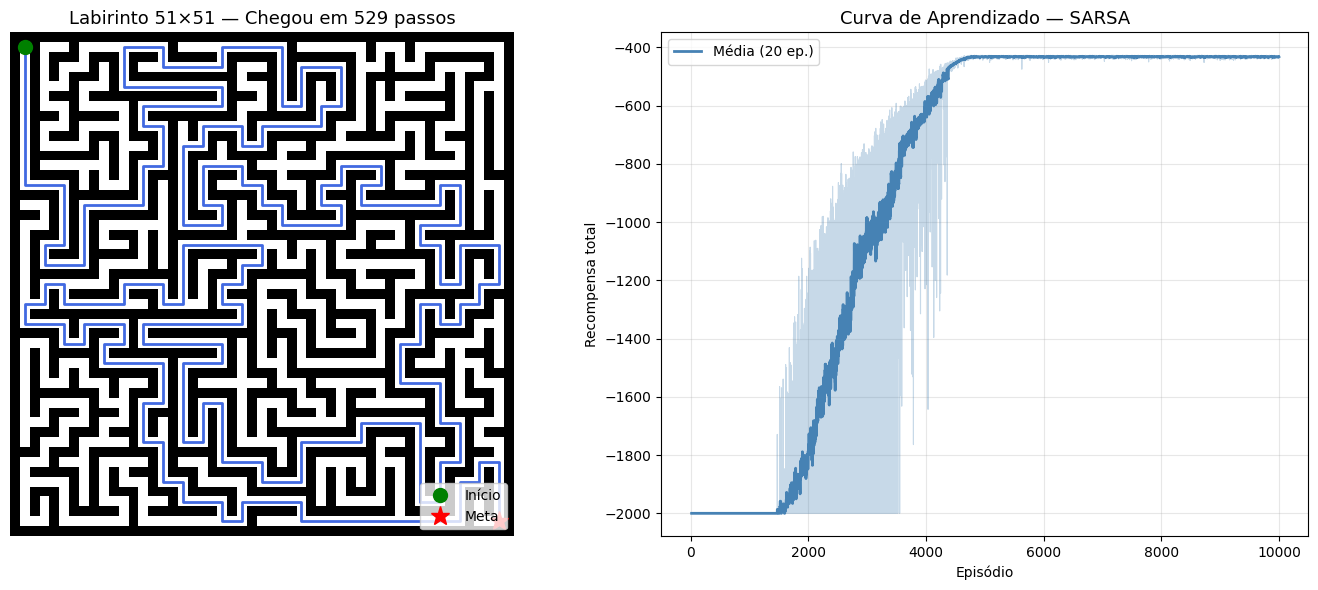

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.imshow(maze, cmap='binary', origin='upper')

# Caminho como linha colorida
if len(caminho) > 1:
    ys = [p[0] for p in caminho]
    xs = [p[1] for p in caminho]
    ax.plot(xs, ys, color='royalblue', linewidth=2, zorder=3)

# Início e meta
ax.plot(START[1], START[0], 'go', markersize=10, label='Início', zorder=5)
ax.plot(GOAL[1],  GOAL[0],  'r*', markersize=14, label='Meta',   zorder=5)

status = f"Chegou em {len(caminho)} passos" if chegou else "Não atingiu a meta"
ax.set_title(f'Labirinto {SIZE}×{SIZE} — {status}', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.axis('off')

ax2 = axes[1]
ax2.plot(recompensas, alpha=0.3, color='steelblue', linewidth=0.8)

janela = 20
media  = np.convolve(recompensas, np.ones(janela)/janela, mode='valid')
ax2.plot(range(janela-1, episodios), media, color='steelblue', linewidth=2,
         label=f'Média ({janela} ep.)')

ax2.set_title('Curva de Aprendizado — SARSA', fontsize=13)
ax2.set_xlabel('Episódio')
ax2.set_ylabel('Recompensa total')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Mapa de Q-Values
Quanto mais quente a célula, maior o valor que o agente aprendeu para ela.

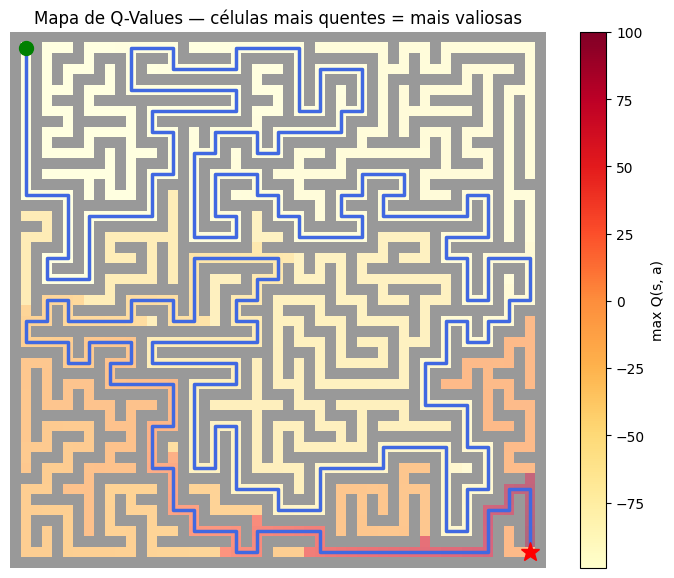

In [42]:
# Q-value máximo por célula
q_max = np.max(Q, axis=2)
q_max[maze == 1] = np.nan  # esconde paredes

fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(q_max, cmap='YlOrRd', origin='upper')
ax.imshow(maze, cmap='binary', origin='upper', alpha=0.4)  # sobrepos paredes

# Caminho
if len(caminho) > 1:
    ys = [p[0] for p in caminho]
    xs = [p[1] for p in caminho]
    ax.plot(xs, ys, color='royalblue', linewidth=2.5, zorder=3)

ax.plot(START[1], START[0], 'go', markersize=10, zorder=5)
ax.plot(GOAL[1],  GOAL[0],  'r*', markersize=14, zorder=5)

plt.colorbar(im, ax=ax, label='max Q(s, a)', shrink=0.8)
ax.set_title('Mapa de Q-Values — células mais quentes = mais valiosas', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 6. Evolução Completa do Aprendizado

Quatro métricas juntas mostram o que acontece ao longo do treino:

| Gráfico | O que revela |
|---|---|
| Recompensa total | Se o agente acumula mais recompensa com o tempo |
| Passos até terminar | Se o agente aprende caminhos mais curtos |
| Taxa de sucesso | Frequência com que o agente chega à meta |
| Epsilon (ε) | Quanto o agente ainda explora vs. explota |

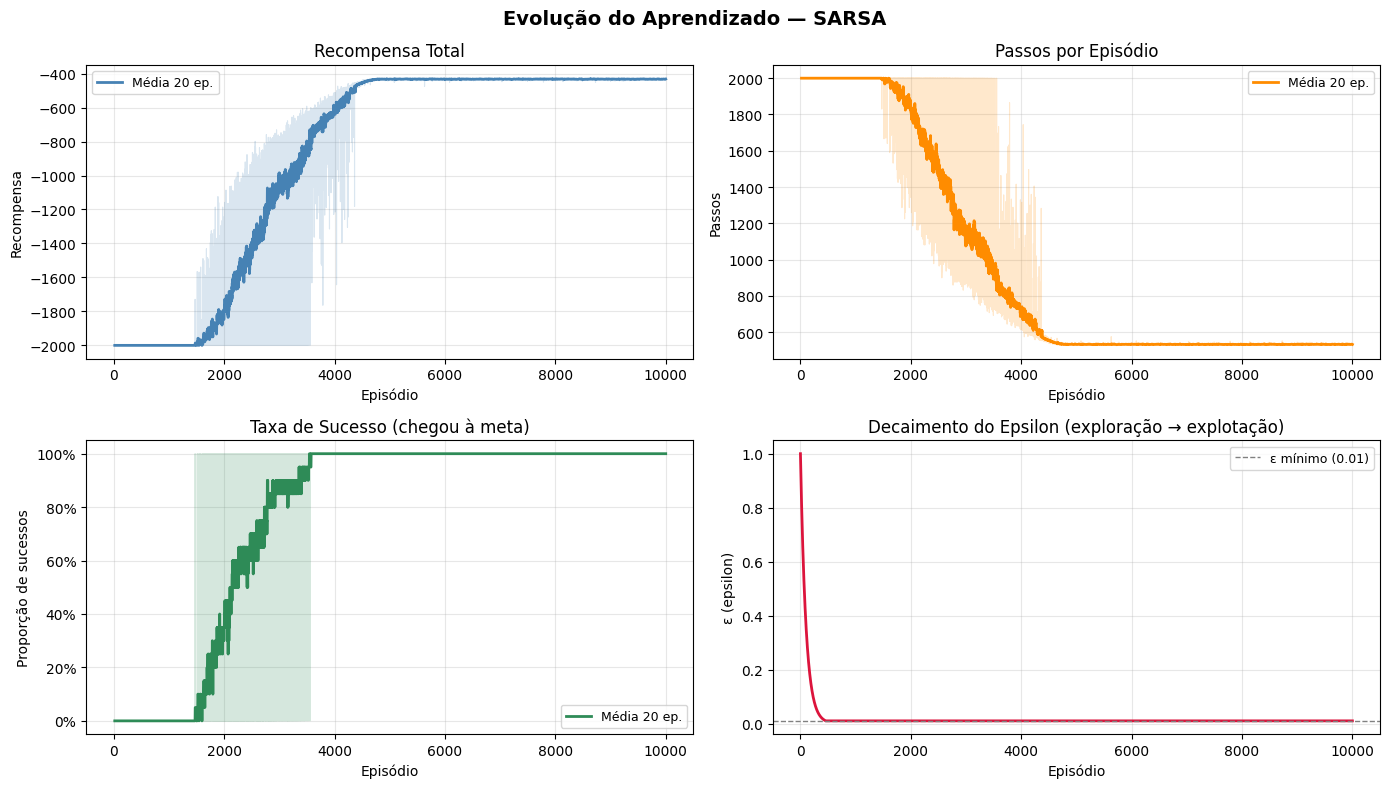

In [43]:
janela = 20  # janela da média móvel

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Evolução do Aprendizado — SARSA', fontsize=14, fontweight='bold')

def plot_serie(ax, dados, cor, titulo, ylabel, janela=janela, pct=False):
    """Plota série bruta (transparente) + média móvel."""
    ax.plot(dados, alpha=0.2, color=cor, linewidth=0.8)
    media = np.convolve(dados, np.ones(janela)/janela, mode='valid')
    ax.plot(range(janela-1, len(dados)), media, color=cor, linewidth=2,
            label=f'Média {janela} ep.')
    if pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Episódio')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# 1. Recompensa total por episódio
plot_serie(axes[0,0], recompensas, 'steelblue',
           'Recompensa Total', 'Recompensa')

# 2. Passos até terminar o episódio
plot_serie(axes[0,1], passos_por_ep, 'darkorange',
           'Passos por Episódio', 'Passos')

# 3. Taxa de sucesso (média móvel)
plot_serie(axes[1,0], sucessos, 'seagreen',
           'Taxa de Sucesso (chegou à meta)', 'Proporção de sucessos', pct=True)

# 4. Decaimento do epsilon
axes[1,1].plot(epsilons, color='crimson', linewidth=2)
axes[1,1].axhline(0.01, color='gray', linestyle='--', linewidth=1, label='ε mínimo (0.01)')
axes[1,1].set_title('Decaimento do Epsilon (exploração → explotação)', fontsize=12)
axes[1,1].set_xlabel('Episódio')
axes[1,1].set_ylabel('ε (epsilon)')
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Política Aprendida

A **política** é a regra de decisão do agente: em cada estado, qual ação tomar?

Após o treino, a política **greedy** escolhe a ação com maior Q-value.
As setas mostram essa escolha em cada célula livre do labirinto.

> Uma política bem aprendida deve ter setas apontando coerentemente em direção à meta.

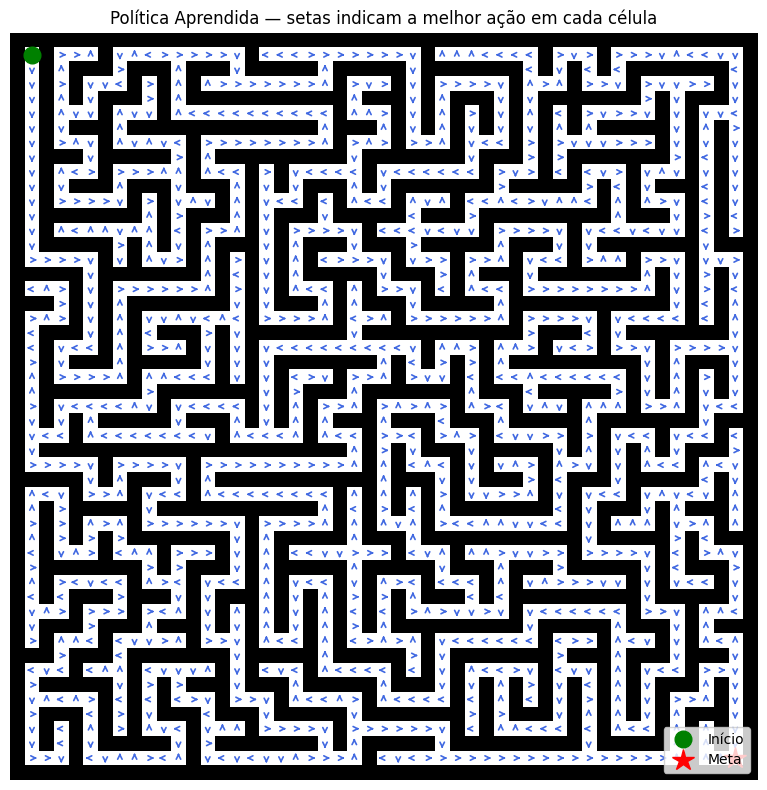

In [44]:
# Mapeamento: índice da ação → (delta_coluna, delta_linha) para quiver
# acoes = [(-1,0),(1,0),(0,-1),(0,1)]  →  cima, baixo, esq, dir
# No matplotlib, eixo y cresce para baixo — invertemos dy
acao_para_seta = {
    0: ( 0,  1),  # cima    → seta aponta para cima  (dy positivo = acima no plot)
    1: ( 0, -1),  # baixo   → seta aponta para baixo
    2: (-1,  0),  # esquerda
    3: ( 1,  0),  # direita
}

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(maze, cmap='binary', origin='upper')

# Desenha seta em cada célula livre (exceto meta)
for r in range(SIZE):
    for c in range(SIZE):
        if maze[r, c] == 1 or (r, c) == GOAL:
            continue
        melhor_acao = int(np.argmax(Q[r, c]))
        dx, dy = acao_para_seta[melhor_acao]
        ax.annotate("", xy=(c + dx*0.35, r - dy*0.35),
                    xytext=(c, r),
                    arrowprops=dict(arrowstyle="->", color='royalblue',
                                   lw=1.2, mutation_scale=8))

ax.plot(START[1], START[0], 'go', markersize=12, zorder=5, label='Início')
ax.plot(GOAL[1],  GOAL[0],  'r*', markersize=16, zorder=5, label='Meta')
ax.set_title('Política Aprendida — setas indicam a melhor ação em cada célula', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 8. Inspecionando a Q-table

A **Q-table** armazena o valor esperado de cada par (estado, ação).
Aqui inspecionamos ela de três formas:
1. Valores numéricos de alguns estados específicos
2. Heatmap de cada ação separadamente
3. Estatísticas gerais da tabela

In [45]:
# 8a. Valores numéricos para estados selecionados
nomes_acoes = ['Cima', 'Baixo', 'Esq.', 'Dir.']
estados_interesse = [START, (SIZE//2, SIZE//2), GOAL]
nomes_estados     = ['Início', 'Centro', 'Meta']

print("=" * 55)
print(f"{'Estado':<12} {'Cima':>8} {'Baixo':>8} {'Esq.':>8} {'Dir.':>8}")
print("=" * 55)
for nome, estado in zip(nomes_estados, estados_interesse):
    r, c = estado
    vals = Q[r, c]
    melhor = np.argmax(vals)
    linha = f"{nome} {estado!s:<8}"
    for i, v in enumerate(vals):
        marker = " <--" if i == melhor else ""
        linha += f"  {v:6.2f}{marker if i == melhor else '      '}"
    print(linha)
print("=" * 55)
print("Seta <-- indica a ação com maior Q-value (política greedy)")

Estado           Cima    Baixo     Esq.     Dir.
Início (1, 1)    -99.37        -99.32 <--  -99.38        -99.38      
Centro (25, 25)  -68.39        -68.36        -68.32        -68.31 <--
Meta (49, 49)    0.00 <--    0.00          0.00          0.00      
Seta <-- indica a ação com maior Q-value (política greedy)


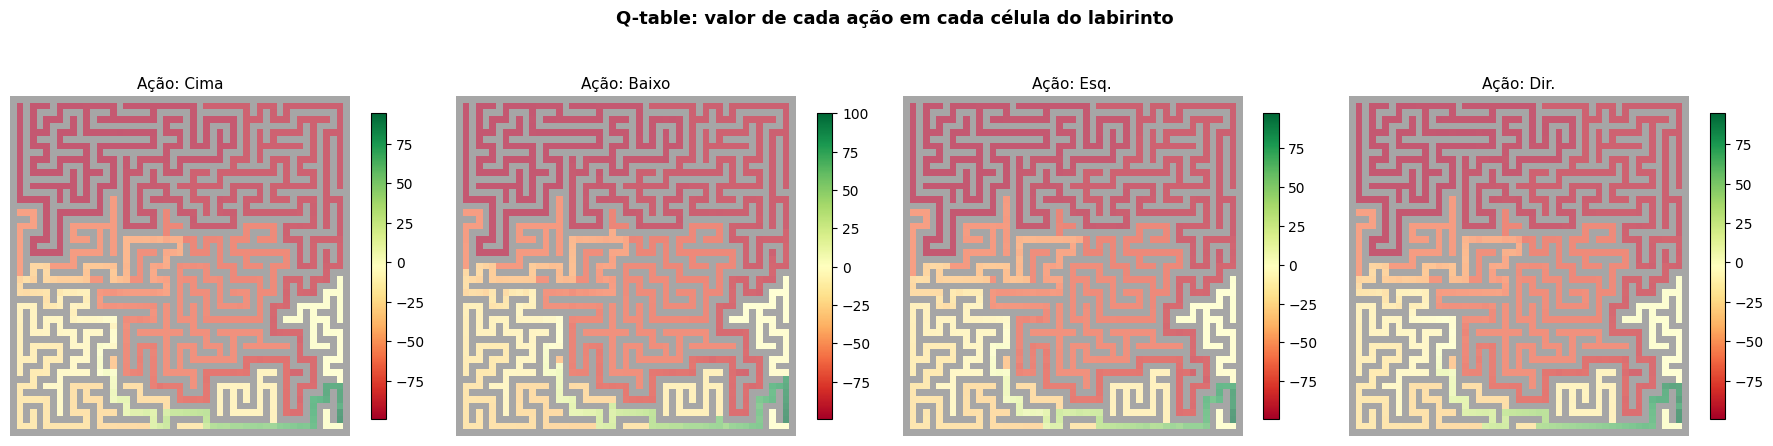

In [46]:
# 8b. Heatmap de Q-values para cada ação
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Q-table: valor de cada ação em cada célula do labirinto', fontsize=13, fontweight='bold')

for i, (ax, nome) in enumerate(zip(axes, nomes_acoes)):
    mapa = Q[:, :, i].copy().astype(float)
    mapa[maze == 1] = np.nan  # oculta paredes
    im = ax.imshow(mapa, cmap='RdYlGn', origin='upper')
    ax.imshow(maze, cmap='binary', origin='upper', alpha=0.35)
    ax.set_title(f'Ação: {nome}', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

In [47]:
# 8c. Estatísticas gerais da Q-table
celulas_livres = maze == 0
q_livre = Q[celulas_livres]  # apenas células acessíveis

print("Estatísticas da Q-table (células livres):")
print(f"  Células livres   : {celulas_livres.sum()}")
print(f"  Entradas totais  : {q_livre.size}  ({celulas_livres.sum()} células × 4 ações)")
print(f"  Q mínimo         : {q_livre.min():.2f}")
print(f"  Q máximo         : {q_livre.max():.2f}")
print(f"  Q médio          : {q_livre.mean():.2f}")
print(f"  Entradas > 0     : {(q_livre > 0).sum()} ({(q_livre > 0).mean()*100:.1f}%)")
print(f"  Entradas = 0     : {(q_livre == 0).sum()} ({(q_livre == 0).mean()*100:.1f}%)  ← estados não visitados")

Estatísticas da Q-table (células livres):
  Células livres   : 1249
  Entradas totais  : 4996  (1249 células × 4 ações)
  Q mínimo         : -99.38
  Q máximo         : 100.00
  Q médio          : -62.57
  Entradas > 0     : 263 (5.3%)
  Entradas = 0     : 53 (1.1%)  ← estados não visitados


---
## 9. Impacto dos Hiperparâmetros

Rodamos o SARSA várias vezes variando **um hiperparâmetro por vez** e comparamos as curvas de aprendizado.

| Hiperparâmetro | O que controla |
|---|---|
| `alpha` (α) | Velocidade de atualização dos Q-values |
| `gamma` (γ) | Importância de recompensas futuras vs. imediatas |
| Decaimento de ε | Velocidade de transição exploração → explotação |

> **Atenção:** este bloco demora alguns segundos — cada configuração treina do zero.

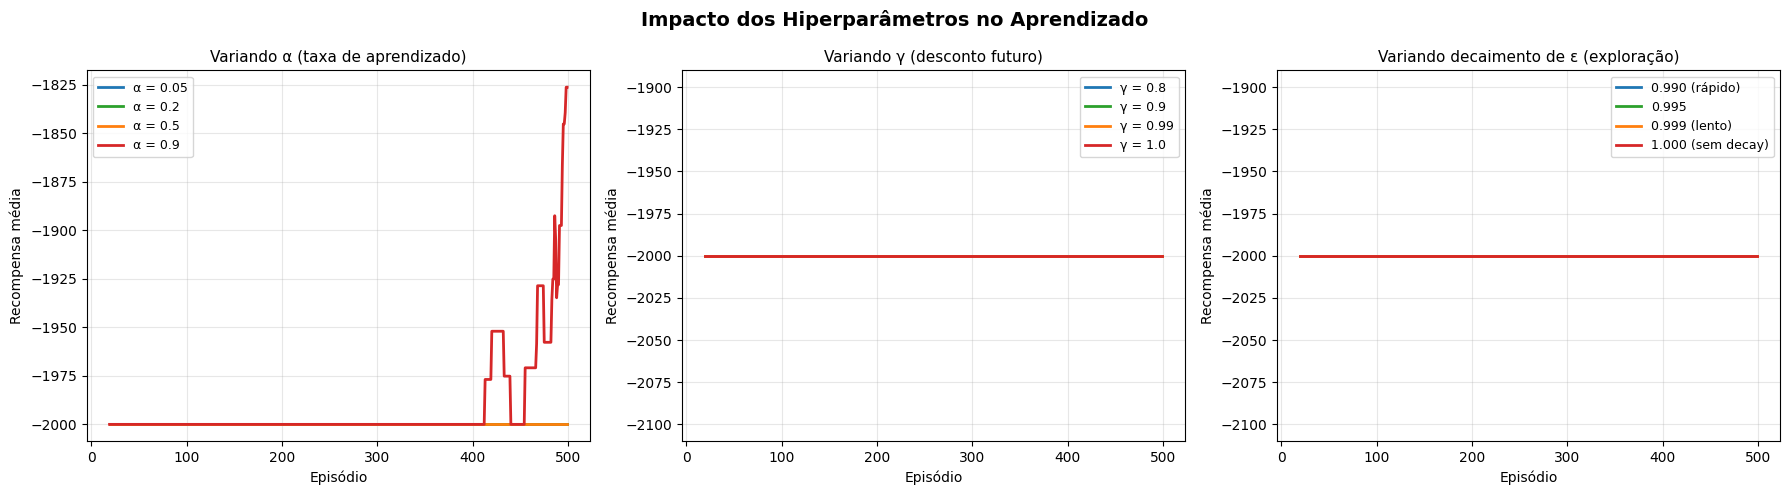

In [48]:
def treinar_sarsa(maze, SIZE, alpha=0.2, gamma=0.99, eps_decay=0.99,
                  episodios=500, max_passos=2000, seed=0):
    """Treina SARSA e retorna (recompensas, sucessos, passos) por episódio."""
    np.random.seed(seed)
    acoes_local = [(-1,0),(1,0),(0,-1),(0,1)]
    Q_local = np.zeros((SIZE, SIZE, 4))
    epsilon = 1.0

    def _acao(r, c, eps):
        if np.random.rand() < eps:
            return np.random.randint(4)
        return int(np.argmax(Q_local[r, c]))

    def _passo(r, c, a):
        dr, dc = acoes_local[a]
        nr, nc = r+dr, c+dc
        if 0 <= nr < SIZE and 0 <= nc < SIZE and maze[nr, nc] == 0:
            r, c = nr, nc
        return r, c, (100 if (r, c) == GOAL else -1)

    recs, sucs, steps = [], [], []
    for _ in range(episodios):
        r, c = START
        a = _acao(r, c, epsilon)
        total, n = 0, 0
        for __ in range(max_passos):
            nr, nc, recomp = _passo(r, c, a)
            na = _acao(nr, nc, epsilon)
            Q_local[r,c,a] += alpha * (recomp + gamma * Q_local[nr,nc,na] - Q_local[r,c,a])
            r, c, a = nr, nc, na
            total += recomp
            n += 1
            if (r, c) == GOAL:
                break
        recs.append(total)
        sucs.append(1 if (r, c) == GOAL else 0)
        steps.append(n)
        epsilon = max(0.01, epsilon * eps_decay)
    return np.array(recs), np.array(sucs), np.array(steps)


def media_movel(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')


EPS = 500
W   = 20  # janela da média móvel
xs  = range(W-1, EPS)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impacto dos Hiperparâmetros no Aprendizado', fontsize=14, fontweight='bold')

#  9a. Variando alpha
ax = axes[0]
alphas = [0.05, 0.2, 0.5, 0.9]
cores  = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
for al, cor in zip(alphas, cores):
    recs, _, _ = treinar_sarsa(maze, SIZE, alpha=al)
    ax.plot(xs, media_movel(recs, W), color=cor, linewidth=2, label=f'α = {al}')
ax.set_title('Variando α (taxa de aprendizado)', fontsize=11)
ax.set_xlabel('Episódio')
ax.set_ylabel('Recompensa média')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

#  9b. Variando gamma
ax = axes[1]
gammas = [0.80, 0.90, 0.99, 1.00]
for gm, cor in zip(gammas, cores):
    recs, _, _ = treinar_sarsa(maze, SIZE, gamma=gm)
    ax.plot(xs, media_movel(recs, W), color=cor, linewidth=2, label=f'γ = {gm}')
ax.set_title('Variando γ (desconto futuro)', fontsize=11)
ax.set_xlabel('Episódio')
ax.set_ylabel('Recompensa média')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

#  9c. Variando decaimento de epsilon
ax = axes[2]
decaimentos = [0.990, 0.995, 0.999, 1.000]  # 1.0 = sem decaimento
rotulos     = ['0.990 (rápido)', '0.995', '0.999 (lento)', '1.000 (sem decay)']
for dec, rot, cor in zip(decaimentos, rotulos, cores):
    recs, _, _ = treinar_sarsa(maze, SIZE, eps_decay=dec)
    ax.plot(xs, media_movel(recs, W), color=cor, linewidth=2, label=rot)
ax.set_title('Variando decaimento de ε (exploração)', fontsize=11)
ax.set_xlabel('Episódio')
ax.set_ylabel('Recompensa média')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
**Resumo dos experimentos:**
- **α alto** → aprende rápido, mas pode ser instável
- **α baixo** → aprendizado mais suave, porém mais lento
- **γ próximo de 1** → agente paciente, valoriza recompensas distantes (necessário no labirinto)
- **γ baixo** → agente míope, ignora recompensas futuras — péssimo para navegação
- **Decaimento rápido de ε** → explota cedo; pode ficar preso em política subótima
- **Sem decaimento (ε fixo)** → explora eternamente; nunca converge

**Outros experimentos:**
- Aumente `episodios` para ver o agente melhorar
- Troque `SIZE = 20` por `SIZE = 30` para um labirinto maior
- Mude o `seed` em `gerar_labirinto()` para um labirinto diferente
- Reduza `episodios = 50` e veja como o caminho piora